Implementing pytorch to the same model

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch


train_df = pd.read_csv("mnist_train.csv", header=None)
test_df = pd.read_csv("mnist_test.csv", header=None)

X_train_np = train_df.iloc[:, 1:].values / 255.0
y_train_np = train_df.iloc[:, 0].values % 2

X_test_np = test_df.iloc[:, 1:].values / 255.0
y_test_np = test_df.iloc[:, 0].values % 2


# Check if GPU is available and set device accordingly
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)


X_train = torch.tensor(X_train_np, dtype=torch.float32, device=device)
y_train = torch.tensor(y_train_np, dtype=torch.float32, device=device)

X_test = torch.tensor(X_test_np, dtype=torch.float32, device=device)
y_test = torch.tensor(y_test_np, dtype=torch.float32, device=device)


# Normalize intesities 
X_train = X_train / 255.0
X_test = X_test / 255.0


# Convert labels to parity 
y_train_binary = y_train % 2
y_test_binary = y_test % 2


torch.manual_seed(0)

W = torch.randn(784, device=device, requires_grad=True) * 0.01
W = W.clone().detach().requires_grad_(True)

b = torch.tensor(0.0, device=device, requires_grad=True)




cpu


In [7]:
# Training loop

learning_rate = 1.0
loops = 2000

losses = []

for epoch in range(loops):
    logits = X_train @ W + b
    y_pred = torch.sigmoid(logits)

    eps = 1e-8
    loss = -torch.mean(
        y_train * torch.log(y_pred + eps)
        + (1 - y_train) * torch.log(1 - y_pred + eps)
    )

    loss.backward()

    with torch.no_grad():
        W -= learning_rate * W.grad
        b -= learning_rate * b.grad

        W.grad.zero_()
        b.grad.zero_()

    losses.append(loss.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 0.6932
Epoch 100, Loss: 0.6924
Epoch 200, Loss: 0.6917
Epoch 300, Loss: 0.6911
Epoch 400, Loss: 0.6904
Epoch 500, Loss: 0.6897
Epoch 600, Loss: 0.6891
Epoch 700, Loss: 0.6884
Epoch 800, Loss: 0.6878
Epoch 900, Loss: 0.6871
Epoch 1000, Loss: 0.6865
Epoch 1100, Loss: 0.6859
Epoch 1200, Loss: 0.6852
Epoch 1300, Loss: 0.6846
Epoch 1400, Loss: 0.6839
Epoch 1500, Loss: 0.6833
Epoch 1600, Loss: 0.6827
Epoch 1700, Loss: 0.6820
Epoch 1800, Loss: 0.6814
Epoch 1900, Loss: 0.6808


In [8]:
# Evaluate accuracy

with torch.no_grad():
    train_pred = torch.sigmoid(X_train @ W + b) >= 0.5
    test_pred = torch.sigmoid(X_test @ W + b) >= 0.5

    train_acc = (train_pred.float() == y_train).float().mean()
    test_acc = (test_pred.float() == y_test).float().mean()

print(f"Train accuracy: {train_acc.item():.4f}")
print(f"Test accuracy: {test_acc.item():.4f}")

Train accuracy: 0.6982
Test accuracy: 0.7076


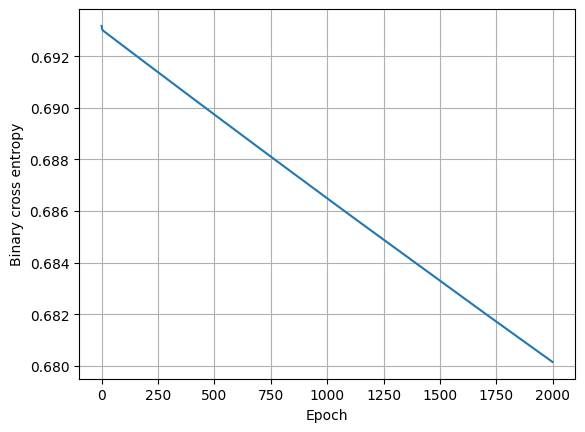

In [9]:
# Plot losses

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Binary cross entropy")
plt.grid(True)
plt.show()